# GNN Optimization with 5-Fold CV

This notebook runs the consolidated optimization script `optimize_gnn_cv5.py`. 
It performs:
1. Dependency Installation
2. Data Loading
3. Stratified 5-Fold Cross-Validation Optimization (Optuna)
4. Retraining on Full Dataset with Best Hyperparameters
5. External Validation on `test_dataset.csv`
6. Architecture Diagram Generation

In [ ]:
# Install Dependencies
!apt-get install graphviz -y
!pip install torch_geometric optuna rdkit torchviz graphviz

In [3]:
# Run the Optimization Script
# Adjust --n_trials as needed for more exhaustive search
!python optimize_gnn_cv5.py --n_trials 50

Using device: cuda
Loading datasets...
Converting to PyG Data...
Starting Optimization (CV-5)...
[I 2025-12-17 10:50:36,341] A new study created in memory with name: no-name-7129c30f-d3fe-4d52-9acd-155e525e3d8c
  >>> NEW BEST CV AVERAGE: 0.9347 (Params: {'model_type': 'GAT', 'num_layers': 3, 'hidden_channels': 64, 'heads': 4, 'dropout': 0.432727396843097, 'lr': 0.00010202119211514438, 'batch_size': 32, 'weight_decay': 0.0001963127575991723})
[I 2025-12-17 10:51:43,655] Trial 0 finished with value: 0.9347400430733763 and parameters: {'model_type': 'GAT', 'num_layers': 3, 'hidden_channels': 64, 'heads': 4, 'dropout': 0.432727396843097, 'lr': 0.00010202119211514438, 'batch_size': 32, 'weight_decay': 0.0001963127575991723}. Best is trial 0 with value: 0.9347400430733763.
  >>> NEW BEST CV AVERAGE: 0.9420 (Params: {'model_type': 'GAT', 'num_layers': 4, 'hidden_channels': 64, 'heads': 8, 'dropout': 0.3973011116693962, 'lr': 0.00019563799154134068, 'batch_size': 32, 'weight_decay': 4.73661233

--- GNN Visualizations ---
-rw-rw-r-- 1 francisco francisco 892K dez 17 11:26 gnn_architecture_diagram.png
-rw-rw-r-- 1 francisco francisco 892K dez 17 11:26 gnn_computational_graph.png

[1] Computational Graph (Generated by TorchViz):


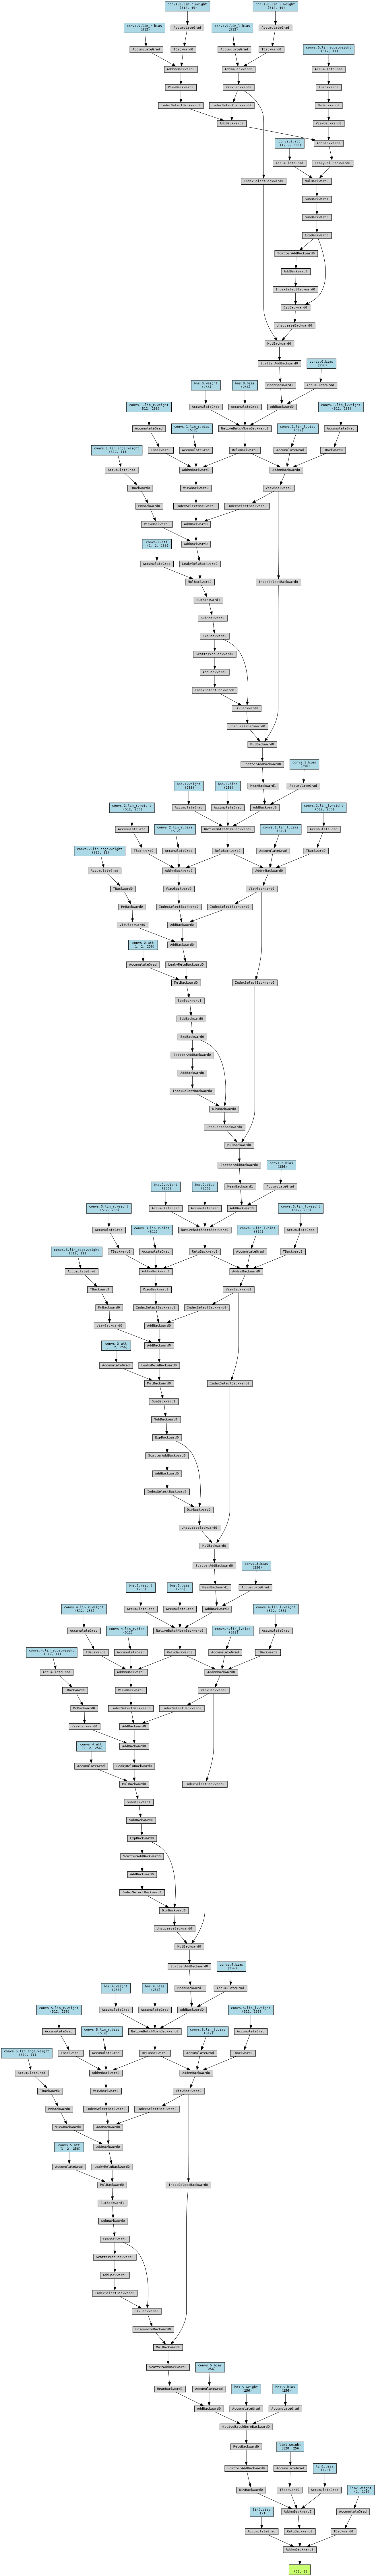


[2] Architecture Diagram:


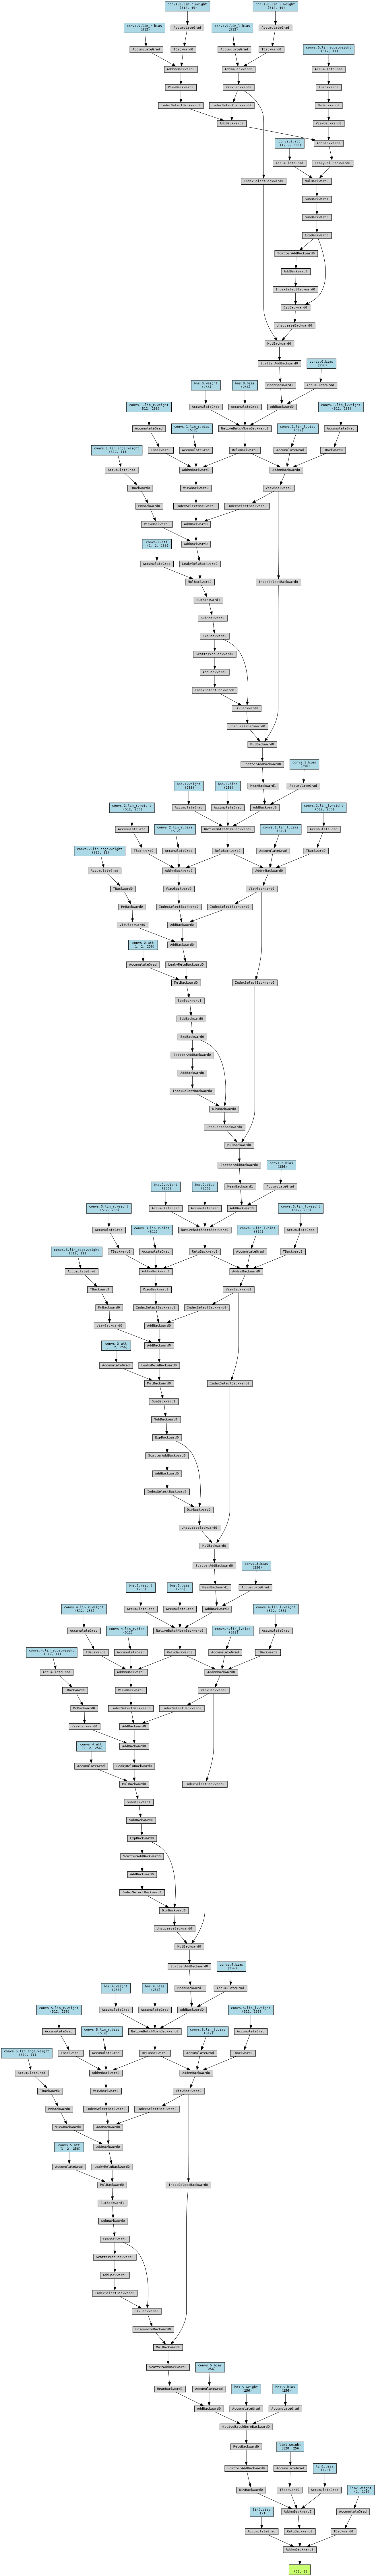

In [4]:
# Display the Generated Diagrams
import os
from IPython.display import Image, display

print("--- GNN Visualizations ---")

# Check what files actually exist
!ls -lh *.png 2>/dev/null || echo "No PNG files found."


# 1. Computational Graph (Detailed)
if os.path.exists('gnn_computational_graph.png'):
    print("\n[1] Computational Graph (Generated by TorchViz):")
    display(Image('gnn_computational_graph.png'))
else:
    print("\n[1] Computational Graph not found.")

# 2. Architecture Diagram (Conceptual/Simplified)
if os.path.exists('gnn_architecture_diagram.png'):
    print("\n[2] Architecture Diagram:")
    display(Image('gnn_architecture_diagram.png'))
else:
    print("\n[2] Architecture Diagram not found.")

# Real-World Prediction

Use the trained model and the **Optimal Threshold** discovered during validation to predict new molecules.

In [12]:
# Method 1: Command Line Usage
# Predict for a single SMILES string (e.g., Vanillin)
!python predict_new.py "Oc1c(OC)cc(C=O)cc1"

Loaded params from best_params.json
Loaded Optimal Threshold: 0.9376

Running predictions on 1 molecules...

SMILES                                   | PROB     | THR    | PREDICTION
---------------------------------------------------------------------------
Oc1c(OC)cc(C=O)cc1                       | 1.0000   | 0.94   | ODOR


In [13]:
# Method 2: Python Interactive Usage
from predict_new import load_prediction_artifacts, predict_smiles

# 1. Load Model & Threshold
model, threshold, device = load_prediction_artifacts()

# 2. Define your molecules
my_molecules = [
    "CCO",             # Ethanol
    "CC(=O)C",         # Acetone
    "c1ccccc1",        # Benzene
    "Oc1c(OC)cc(C=O)cc1" # Vanillin
]

# 3. Run Prediction
results = predict_smiles(model, threshold, device, my_molecules)

# 4. Display Results
import pandas as pd
df_res = pd.DataFrame(results)
display(df_res)

/home/francisco/anaconda3/envs/ia/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded params from best_params.json
Loaded Optimal Threshold: 0.9376


,SMILES,Valid,Prediction,Prob,Threshold
0,CCO,True,NO ODOR,0.237047,0.937611
1,CC(=O)C,True,ODOR,1.000000,0.937611
2,c1ccccc1,True,ODOR,1.000000,0.937611
3,Oc1c(OC)cc(C=O)cc1,True,ODOR,1.000000,0.937611
